# [1교시]

## 엔드 투 엔드 신경망 훈련 파이프라인

### PyTorch 학습 파이프라인 전체 흐름
- 1단계 : 데이터 준비
    - Dataset -> DataLoader (미니배치 자동 분할)

- 2단계 : 모델 정의
    - nn.Module 클래스 상속 -> __init__ + forward 메서드    (forward 메서드 : 데이터 예측하는 기능을 넣는다)

- 3단계 : 손실 함수 선택
    - nn.MSELoss (회귀) / nn.CrossEntropyLoss (분류)

- 4단계 : 옵티마이저(최적화기) 선택
    - optim.SGD / optim.Adam 등

- 5단계 : 학습 루프(에폭 반복)
    - for epoch in range(에폭수):
        - for batch in DataLoader:
            - Forward:  예측 = model(입력)
            - Loss:     손실 = criterion(예측, 정답)
            - Zero:     optimizer.zero_grad()
            - Backward: loss.backward()
            - Step:     optimizer.step()

- 6단계 : 평가
        - with torch.no_grad(): 정확도(Accuracy) 측정

In [ ]:
# 파이토치에서 모든 신경망은 nn.Module을 상속받아 만든다
class MyNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        # 여기에 레이어(부품) 선언
        self.layer1 = nn.Linear(입력크기, 은닉크기) # 입력크기 : 데이터의 특성
        self.layer2 = nn.Linear(은닉크기, 출력크기)
    
    def forward(self, x):
        # 여기에 순전파 흐름 작성 (모듈 2에서 배운 것)
        x = torch.relu(self.layer1(x))  # 은닉층
        x = self.layer(2)               # 출력층
        return x

## Dastaset / DataLoader: 미니배치 자동 관리자
    - 전체 데이터를 한 번에 넣으면 메모리/일반화 측면에서 비효울적, DataLoa

### 손실 함수(criterion)는 무엇을 기준으로 고르나?
    - 1. 회귀(숫자예측): nn.MSELoss()

    - 2. 이진 분류: nn.BCEWithLogitsLoss()

    - 3. 다중 분류(클래스 3개 이상): nn.CrossEntropyLoss()

### 학습 루프 5단계의 의미
    - 1. Forward: pred = model(x)           (순전파 계산 흐름)

    - 2. Loss: loss = criterion(pred, y)    (손실 함수)

    - 3. Zero Grad: optimizer.zero_grad()   (이전 루프의 기울기 잔여값 초기화 (누적방지))

    - 4. Backward: loss.backward()          오차 역전파 (연쇄 법칙)

    - 5. optimizer.step()                   (경사하강법)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
torch.manual_seed(42)

In [ ]:
X_xor = torch.tensor([[0.0, 0.0], # 0    0 0
                     [0.0, 1.0], # 1    0 1
                     [1.0, 0.0], # 1    0 1
                     [1.0, 1.0]]) # 1    1 0

y_xor = torch.tensor([[0.0],
                     [1.0],
                     [1.0],
                     [0.0]])

# [2교시]

In [ ]:
class XORNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(2, 4)
        self.output = nn.Linear(4, 1)
    def forward(self, x):
        x = torch.relu(self.hidden(x))  #차원의 수를 예측할 수 없기 때문에 반드시 hidden으로 가야한다
        x = torch.sigmoid(self.output(x))
        return x

model = XORNet()
    
for p in model.parameters():
    print(f'학습가능한 파라미터 수 : {p.numel()}')
    print(f'가중치 및 바이어스 값 : {p.data}')

In [ ]:
# 손실함수, optimizer
criterion = nn.BCELoss()            # 오타 cirterion -> criterion
optimizer = optim.Adam(model.parameters(), lr=1e-2)     #0.01   1e+2    100

In [ ]:
epochs = 10
loss_history = []
for epoch in range(epochs):
    # forward :     순전파(예측)
    predict = model(X_xor)
    # loss 계산
    loss = criterion(predict, y_xor)
    # 기울기 초기화   zero grad()
    optimizer.zero_grad()
    # backward      역전파(체이닝룰) 각 계산스텝별 기울기 계산
    loss.backward()
    # 업데이트       이전기울기 - backward에서 구한 기울기
    optimizer.step()
    # loss_history  loss 저장
    loss_history.append(loss.item())
    if (epoch+1) % 200 == 0:
        print(f'epoch : {epoch+1 / epochs} loss : {loss.item()}')
    

In [ ]:
plt.plot(range(1, epochs+1), loss_history)
plt.show()

epoch: 2 / 1000  loss: 0.686023
epoch: 4 / 1000  loss: 0.682842
epoch: 6 / 1000  loss: 0.680020
epoch: 8 / 1000  loss: 0.676879
epoch: 10 / 1000  loss: 0.673368
epoch: 12 / 1000  loss: 0.669762
epoch: 14 / 1000  loss: 0.665775
epoch: 16 / 1000  loss: 0.661530
epoch: 18 / 1000  loss: 0.657086
epoch: 20 / 1000  loss: 0.652286
epoch: 22 / 1000  loss: 0.647213
epoch: 24 / 1000  loss: 0.641881
epoch: 26 / 1000  loss: 0.636098
epoch: 28 / 1000  loss: 0.629954
epoch: 30 / 1000  loss: 0.623399
epoch: 32 / 1000  loss: 0.616477
epoch: 34 / 1000  loss: 0.609626
epoch: 36 / 1000  loss: 0.602454
epoch: 38 / 1000  loss: 0.594921
epoch: 40 / 1000  loss: 0.587171
epoch: 42 / 1000  loss: 0.579860
epoch: 44 / 1000  loss: 0.571563
epoch: 46 / 1000  loss: 0.563560
epoch: 48 / 1000  loss: 0.554945
epoch: 50 / 1000  loss: 0.546152
epoch: 52 / 1000  loss: 0.537405
epoch: 54 / 1000  loss: 0.527946
epoch: 56 / 1000  loss: 0.519064
epoch: 58 / 1000  loss: 0.509558
epoch: 60 / 1000  loss: 0.499972
epoch: 62 / 10

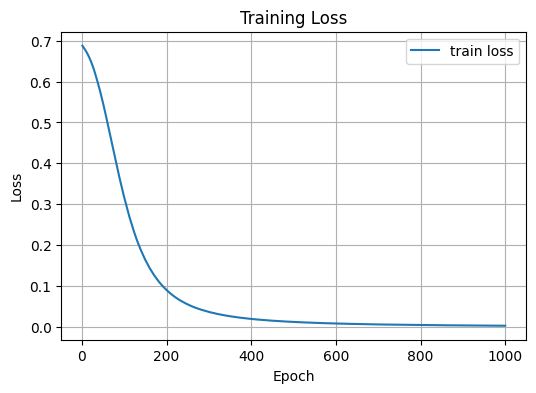

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(0)

# 모델 (출력에서 sigmoid 제거하고 BCEWithLogitsLoss 사용 권장)
class XORNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(2, 4)
        self.output = nn.Linear(4, 1)
    def forward(self, x):
        x = torch.relu(self.hidden(x))
        return self.output(x)   # sigmoid 제거

model = XORNet()

# 데이터
X_xor = torch.tensor([[0.0,0.0],[0.0,1.0],[1.0,0.0],[1.0,1.0]], dtype=torch.float32)
y_xor = torch.tensor([[0.0],[1.0],[1.0],[0.0]], dtype=torch.float32)

# 손실과 옵티마이저
criterion = nn.BCEWithLogitsLoss()   # 안정적
optimizer = optim.Adam(model.parameters(), lr=1e-2)

# 학습
epochs = 1000
loss_history = []
for epoch in range(epochs):
    pred = model(X_xor)                     # logits
    loss = criterion(pred, y_xor)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())
    if (epoch + 1) % 2 == 0:                # 짧은 예시라 2마다 출력
        print(f'epoch: {epoch+1} / {epochs}  loss: {loss.item():.6f}')

# 예측 확인 (sigmoid 적용해서 확률로 변환)
with torch.no_grad():
    probs = torch.sigmoid(model(X_xor))
    print("pred probs:", probs.squeeze().tolist())
    print("targets   :", y_xor.squeeze().tolist())

plt.figure(figsize=(6,4))
plt.plot(range(1, epochs+1), loss_history, label='train loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True)
plt.legend()   # 라벨이 있으므로 안전
plt.show()


학습가능한 파라미터 수 : 8
가중치 및 바이어스 값 : tensor([[ 0.5406,  0.5869],
        [-0.1657,  0.6496],
        [-0.1549,  0.1427],
        [-0.3443,  0.4153]])
학습가능한 파라미터 수 : 4
가중치 및 바이어스 값 : tensor([ 0.6233, -0.5188,  0.6146,  0.1323])
학습가능한 파라미터 수 : 4
가중치 및 바이어스 값 : tensor([[ 0.3694,  0.0677,  0.2411, -0.0706]])
학습가능한 파라미터 수 : 1
가중치 및 바이어스 값 : tensor([0.3854])
epoch : 2 / 1000  loss : 0.796679
epoch : 4 / 1000  loss : 0.778504
epoch : 6 / 1000  loss : 0.762143
epoch : 8 / 1000  loss : 0.747485
epoch : 10 / 1000  loss : 0.734464
epoch : 12 / 1000  loss : 0.722998
epoch : 14 / 1000  loss : 0.713593
epoch : 16 / 1000  loss : 0.705713
epoch : 18 / 1000  loss : 0.699058
epoch : 20 / 1000  loss : 0.693508
epoch : 22 / 1000  loss : 0.688870
epoch : 24 / 1000  loss : 0.685023
epoch : 26 / 1000  loss : 0.681992
epoch : 28 / 1000  loss : 0.679265
epoch : 30 / 1000  loss : 0.676988
epoch : 32 / 1000  loss : 0.674757
epoch : 34 / 1000  loss : 0.672465
epoch : 36 / 1000  loss : 0.670029
epoch : 38 / 1000  loss 

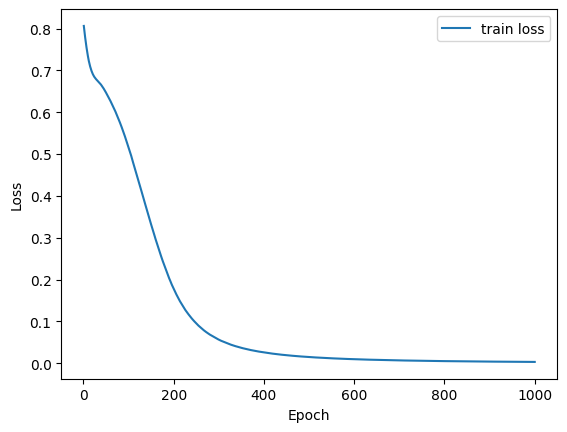

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
torch.manual_seed(42)

# 디바이스를 CPU로 강제 지정
device = torch.device("cpu")

# 데이터
X_xor = torch.tensor([[0.0, 0.0],
                      [0.0, 1.0],
                      [1.0, 0.0],
                      [1.0, 1.0]], dtype=torch.float32).to(device)

y_xor = torch.tensor([[0.0],
                      [1.0],
                      [1.0],
                      [0.0]], dtype=torch.float32).to(device)

# 모델 정의
class XORNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(2, 4)
        self.output = nn.Linear(4, 1)
    def forward(self, x):
        x = torch.relu(self.hidden(x))
        x = torch.sigmoid(self.output(x))
        return x

model = XORNet().to(device)

# 파라미터 출력
for p in model.parameters():
    print(f'학습가능한 파라미터 수 : {p.numel()}')
    print(f'가중치 및 바이어스 값 : {p.data}')

# 손실함수, optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-2)

# 학습 루프
epochs = 1000
loss_history = []
for epoch in range(epochs):
    predict = model(X_xor)
    loss = criterion(predict, y_xor)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())
    if (epoch+1) % 2 == 0:
        print(f'epoch : {epoch+1} / {epochs}  loss : {loss.item():.6f}')

# 학습 곡선 그리기
plt.plot(range(1, epochs+1), loss_history, label="train loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


# [3교시]

In [ ]:
from sklearn.datasets import load_iris
X = torch.tensor(load_iris().data, dtype=torch.float32)
y = torch.tensor(load_iris().target, dtype=torch.long)

In [ ]:
train_dataset = TensorDataset(X_xor, y_xor)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
for data in train_loader:
    print(data)
    break

# [강사님과 함께]

실습 2: 붓꽃(Iris) 3종 분류 파이프라인
실전 데이터셋(150개 샘플, 4개 특성, 3개 종)을 사용하여 DataLoader 미니배치 → 학습 → 평가까지 완전한 파이프라인을 구성합니다.

Step 1. 데이터 준비 (sklearn 활용)

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

# 데이터 로드
iris = load_iris()
X_np, y_np = iris.data, iris.target
print(f"전체 데이터: {X_np.shape[0]}개, 특성 {X_np.shape[1]}개, 종류 {len(set(y_np))}개")
print(f"종 이름: {iris.target_names.tolist()}")

# 학습/테스트 분리 (80:20)
X_train_full, X_test, y_train_full, y_test = train_test_split(X_np, y_np, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)

# 정규화 (특성 스케일 통일)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_val = scaler.transform(X_val)

# 파이토치 텐서로 변환
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)


# DataLoader 구성 (미니배치 자동 관리)
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

print(f"\n학습 데이터: {len(X_train_t)}개, 테스트 데이터: {len(X_test_t)}개 검증 데이터: {len(X_val_t)}개")
print(f"미니배치 크기: 16, 에폭당 반복 횟수: {len(train_loader)}")

전체 데이터: 150개, 특성 4개, 종류 3개
종 이름: ['setosa', 'versicolor', 'virginica']

학습 데이터: 96개, 테스트 데이터: 30개 검증 데이터: 24개
미니배치 크기: 16, 에폭당 반복 횟수: 6


# [4교시]

Step 2. 다중 분류 신경망 정의

In [2]:
class IrisClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(4, 16)    # 입력 4개 특성 → 은닉 16개 뉴런
        self.layer2 = nn.Linear(16, 8)    # 은닉 16 → 은닉 8
        self.layer3 = nn.Linear(8, 3)     # 은닉 8 → 출력 3개 (3종 분류)
    
    def forward(self, x):
        x = torch.relu(self.layer1(x))    # 은닉층 1 (ReLU)
        x = torch.relu(self.layer2(x))    # 은닉층 2 (ReLU)
        x = self.layer3(x)                # 출력층 (softmax는 CrossEntropyLoss 내부에서 자동 적용)
        return x

model_iris = IrisClassifier()
print(model_iris)
print(f"\n총 파라미터 수: {sum(p.numel() for p in model_iris.parameters())}")

IrisClassifier(
  (layer1): Linear(in_features=4, out_features=16, bias=True)
  (layer2): Linear(in_features=16, out_features=8, bias=True)
  (layer3): Linear(in_features=8, out_features=3, bias=True)
)

총 파라미터 수: 243


Step 3. 손실 함수 + 옵티마이저

In [3]:
# 다중 분류 → CrossEntropyLoss (모듈 3에서 배운 CE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_iris.parameters(), lr=0.01)

# [5교시]

Step 4. 학습 루프 (DataLoader + 5단계)

In [4]:
epochs = 100
epoch_losses, epoch_val_losses = [], []
epoch_acces , epoch_val_acces = [],[]

for epoch in range(epochs):
    epoch_loss = 0.0
    epoch_acc = 0.0

    for batch_X, batch_y in train_loader:     # DataLoader가 미니배치를 자동 제공
      # ① Forward
      predictions = model_iris(batch_X)
      # ② Loss
      loss = criterion(predictions, batch_y)
      # ③ Zero Grad
      optimizer.zero_grad()
      # ④ Backward
      loss.backward()
      # ⑤ Step
      optimizer.step()
      epoch_loss += loss.item()
      
      acc = torch.softmax(predictions,axis=1)
      _,class_index = torch.max(acc,dim=1)
      acc = sum(class_index == batch_y) / len(batch_y)
      epoch_acc+= acc.item()

    avg_acc = epoch_acc / len(train_loader)
    epoch_acces.append(avg_acc)

    avg_loss = epoch_loss / len(train_loader)
    epoch_losses.append(avg_loss)




    with torch.no_grad():
      val_predict = model_iris(X_val_t)
      val_loss = criterion(val_predict, y_val_t).item()
      epoch_val_losses.append(val_loss)

      _, val_acc_index = torch.max(torch.softmax(val_predict, axis=1), dim=1)
      val_acc = sum(val_acc_index == y_val_t) / len(y_val_t)
      epoch_val_acces.append(val_acc)


    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1:3d}/{epochs}] \
        - 평균 Loss: {avg_loss:.4f} val loss {val_loss:.4f} \
        - 평균 ACC: {avg_acc:.4f} "
        )

Epoch [ 20/100]         - 평균 Loss: 0.0481 val loss 0.2078         - 평균 ACC: 0.9792 
Epoch [ 40/100]         - 평균 Loss: 0.0238 val loss 0.3384         - 평균 ACC: 0.9896 
Epoch [ 60/100]         - 평균 Loss: 0.0070 val loss 0.4536         - 평균 ACC: 1.0000 
Epoch [ 80/100]         - 평균 Loss: 0.0037 val loss 0.5902         - 평균 ACC: 1.0000 
Epoch [100/100]         - 평균 Loss: 0.0022 val loss 0.6652         - 평균 ACC: 1.0000 


Step 5. 평가 (Evaluation)

테스트 정확도: 96.7% (29/30)


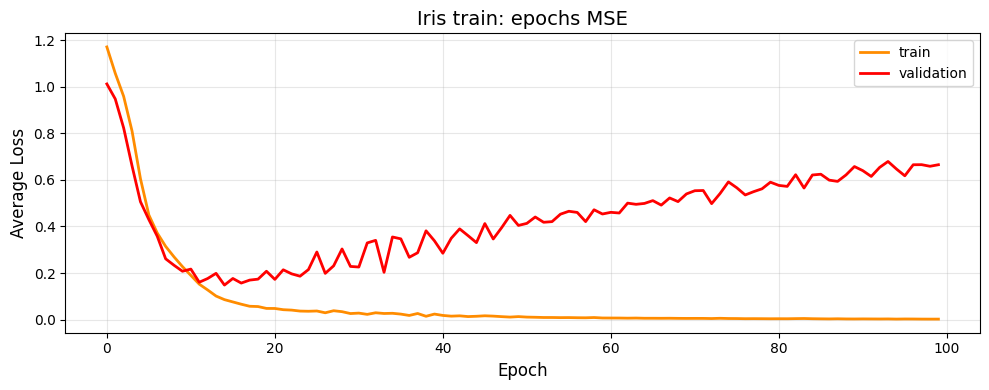

In [5]:
# 평가 모드: 기울기 계산 불필요 (메모리 절약)
import matplotlib.pyplot as plt

with torch.no_grad():
    test_outputs = model_iris(X_test_t)
    _, predicted = torch.max(test_outputs, dim=1)  # 가장 높은 확률의 클래스 선택

    correct = (predicted == y_test_t).sum().item()
    total = y_test_t.size(0)
    accuracy = correct / total * 100

print("=" * 50)
print(f"테스트 정확도: {accuracy:.1f}% ({correct}/{total})")
print("=" * 50)

# 손실 감소 그래프
plt.figure(figsize=(10, 4))
plt.plot(epoch_losses, color='darkorange', linewidth=2, label='train')
plt.plot(epoch_val_losses, color='red', linewidth=2, label='validation')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Average Loss', fontsize=12)
plt.title('Iris train: epochs MSE', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

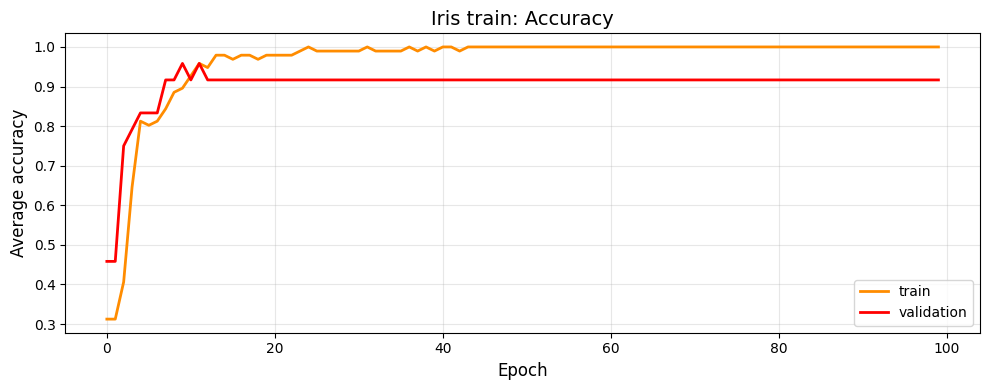

In [6]:
plt.figure(figsize=(10, 4))
plt.plot(epoch_acces, color='darkorange', linewidth=2, label='train')
plt.plot(epoch_val_acces, color='red', linewidth=2, label='validation')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Average accuracy', fontsize=12)
plt.title('Iris train: Accuracy', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 7.1 DNN의 기본 계산식 (회귀/분류 공통)

한 층의 기본 연산은 다음 두 단계입니다.

1. 선형결합:  
   $$
   z^{(l)} = W^{(l)}a^{(l-1)} + b^{(l)}
   $$
2. 활성화:  
   $$
   a^{(l)} = \phi(z^{(l)})
   $$

이것을 여러 층 반복하면 DNN이 됩니다.

```python
z = x @ W.T + b
a = activation(z)
```

## 7.2 회귀: MSE 손실을 코드로 유도

출력이 실수 하나인 회귀를 가정합니다.

$$
\hat{y} = f_\theta(x), \quad
L_{MSE} = \frac{1}{N}\sum_{i=1}^N(\hat{y}_i - y_i)^2
$$

개별 샘플 기준 미분:
$$
\frac{\partial L}{\partial \hat{y}} = 2(\hat{y} - y)
$$

가중치 업데이트(경사하강법):
$$
\theta \leftarrow \theta - \eta \frac{\partial L}{\partial \theta}
$$

# [6교시]

## 7.3 분류: Cross-Entropy를 코드로 유도

아래 순서대로 보면 Cross-Entropy가 왜 그렇게 동작하는지 자연스럽게 연결됩니다.

### 7.3.1 1단계: 모델 출력은 확률이 아니라 로짓(logits)

모델은 클래스별 점수(로짓) 벡터를 냅니다.
$$
z = [z_1, z_2, \ldots, z_K]
$$
여기서 `K`는 전체 클래스 개수이고, 벡터 `z`의 길이도 `K`입니다.  
$z_i$는 $i$번 클래스의 점수이며, 예를 들어 클래스가 `[고양이, 강아지, 토끼]`면
$$
z = [2.1, 0.3, -1.0]
$$
처럼 각 클래스 점수가 1:1로 들어갑니다.  
이 값은 음수/양수 아무 값이나 가능하고, 합이 1일 필요도 없습니다.

### 7.3.2 2단계: softmax로 확률로 변환

먼저 수식에 나오는 용어를 정리합니다.
| 수식 | 의미 |
| --- | --- |
| $z_k$ | $k$번 클래스의 로짓(원점수) |
| $e^{z_k}$ | 로짓을 지수화한 값(항상 양수) |
| $\sum_j e^{z_j}$ | 모든 클래스의 지수화 점수 총합(정규화 기준) |
| $p_k$ | 최종적으로 얻는 $k$번 클래스 확률 |

지수함수 $e^x$를 짧게 짚고 넘어가면 softmax가 더 자연스럽습니다.
1. $e^x$는 항상 양수입니다. (예: $e^2 \approx 7.39,\ e^0 = 1,\ e^{-1} \approx 0.37$)
2. 입력이 커질수록 출력이 더 빠르게 커집니다.
3. 큰 점수는 더 크게, 작은 점수는 더 작게 벌려서 클래스 간 차이를 강조합니다.

왜 이런 형태가 나오냐면, 목표가 다음 2가지를 동시에 만족해야 하기 때문입니다.
1. 각 클래스 점수를 확률처럼 해석 가능하게 만들기(음수 불가, 0~1 범위)
2. 클래스 전체 확률 합이 1이 되게 만들기

유도 직관은 간단합니다.
1. 로짓은 음수/양수 아무 값이므로 바로 확률로 쓰기 어렵다.
2. 그래서 각 로짓에 지수 함수를 적용해 모든 값을 양수로 만든다.
3. 그다음 지수화 값의 전체 합으로 나눠 정규화하면 합이 1이 된다.

이 과정을 식으로 쓰면:
$$
p_k = \frac{e^{z_k}}{\sum_j e^{z_j}}
$$

파이썬 코드로 쓰면 다음과 같습니다.

```python
import numpy as np

z = np.array([2.0, 1.0, 0.0])          # logits
exp_z = np.exp(z - np.max(z))          # 수치 안정성(overflow 방지)
p = exp_z / exp_z.sum()                # softmax 확률

print(p)        # [0.66524096 0.24472847 0.09003057]
print(p.sum())  # 1.0
```

로짓(logit)은 **확률로 바꾸기 전의 원점수(raw score)** 로, 값이 클수록 해당 클래스가 더 유력하다는 모델의 신호입니다.  
즉, 로짓 벡터를 softmax에 넣으면 클래스별 확률 벡터가 나오고, 그중 k번째 값이 위에서 정의한 확률 값입니다.

이렇게 정의된 확률은 다음 성질을 가집니다.
1. 각 값이 0~1 사이
2. 전체 합이 1
3. 값이 클수록 그 클래스 확률이 큼

간단한 숫자 대입으로 바로 확인해봅시다.
1. 로짓을 `[2, 1, 0]`으로 둡니다.
2. 지수화하면 $[e^2, e^1, e^0] = [7.389, 2.718, 1.000]$
3. 합은 `11.107`
4. 정규화:

$$
p_1 = \frac{7.389}{11.107} \approx 0.665,\quad
p_2 = \frac{2.718}{11.107} \approx 0.245,\quad
p_3 = \frac{1.000}{11.107} \approx 0.090
$$

5. 세 확률의 합은 `0.665 + 0.245 + 0.090 = 1.000` (반올림 오차 제외)

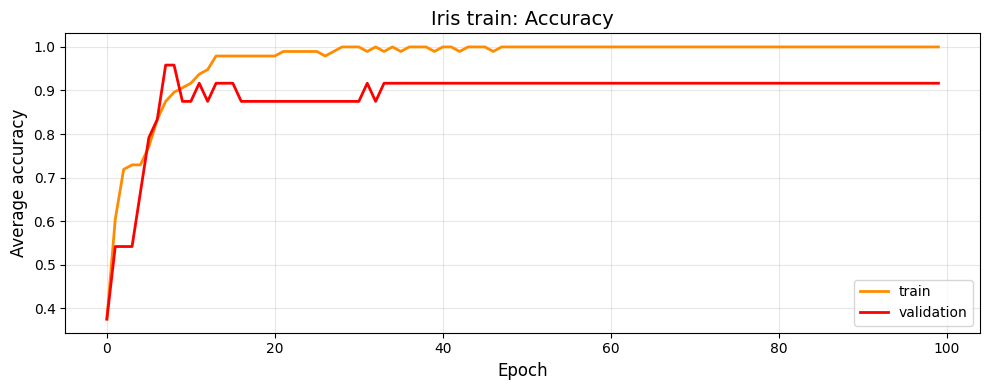

In [12]:
plt.figure(figsize=(10, 4))
plt.plot(epoch_acces, color='darkorange', linewidth=2, label='train')
plt.plot(epoch_val_acces, color='red', linewidth=2, label='validation')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Average accuracy', fontsize=12)
plt.title('Iris train: Accuracy', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
import torch
x = torch.tensor([1, 0, -1])
torch.exp(x)

tensor([2.7183, 1.0000, 0.3679])

### 7.3.3 3단계: 정답 클래스 확률만 뽑아 Cross-Entropy(CE) 손실 계산

정답 인덱스를 `t`라 하면,

$$
L_{CE} = -\log p_t
$$

핵심 직관:
1. $p_t$ 가 크면(정답을 잘 맞추면) 손실이 작아짐
2. $p_t$ 가 작으면(정답을 놓치면) 손실이 급격히 커짐

### 7.3.4 4단계: 숫자 예시 1 (맞춘 경우)

3개 클래스에서 로짓이 `[2.0, 1.0, 0.1]`라고 합시다.  
softmax 확률은 대략 `[0.659, 0.242, 0.099]`가 됩니다.

정답이 클래스 0이면:

$$
L = -\log(0.659) \approx 0.417
$$

손실이 비교적 작습니다.

### 7.3.5 5단계: 숫자 예시 2 (틀린 경우)

같은 확률에서 정답이 클래스 2라면:

$$
L = -\log(0.099) \approx 2.313
$$

손실이 크게 증가합니다.  
즉, **정답 확률을 높이는 방향**으로만 강하게 압력이 걸립니다.

### 7.3.6 6단계: 역전파에서 왜 단순해지는가

softmax와 Cross-Entropy(CE)를 합치면 로짓에 대한 미분이 깔끔해집니다.

왜 이 미분을 하냐면, 학습에서 우리가 실제로 업데이트하는 것은 가중치 $W,b$이고  
업데이트에 필요한 값은 $\frac{\partial L}{\partial W}, \frac{\partial L}{\partial b}$이기 때문입니다.  
그 직전 단계가 마지막 출력 로짓 $z_k$이므로 먼저 $\frac{\partial L}{\partial z_k}$를 구해 연쇄법칙으로 뒤로 전파합니다.

즉, 아래 식은 **손실 $L$을 로짓 $z_k$로 미분한 값**입니다.

$$
\frac{\partial L}{\partial z_k} = p_k - \mathbb{1}(k=t)
$$

여기서 핵심은 **$\frac{\partial L}{\partial z_k}$ (손실을 로짓으로 미분)** 

왜 오른쪽처럼 되냐면, CE와 softmax를 **각각** 미분해서 연쇄법칙으로 곱하기 때문입니다.

먼저 두 식은 다음과 같습니다.
$$
\text{CE: } L=-\log p_t,\qquad
\text{softmax: } p_i=\frac{e^{z_i}}{\sum_j e^{z_j}}
$$

그리고 미분은 두 단계로 구분됩니다.
1. **CE를 미분**: $L=-\log p_t$를 $p_t$로 미분하여 $\frac{\partial L}{\partial p_t}=-\frac{1}{p_t}$
2. **softmax를 미분**: $p_t$를 $z_k$로 미분하여 $\frac{\partial p_t}{\partial z_k}$를 구함

그다음 연쇄법칙으로
$$
\frac{\partial L}{\partial z_k}
=
\frac{\partial L}{\partial p_t}
\cdot
\frac{\partial p_t}{\partial z_k}
$$
가 되고, 결과가 두 경우로 나뉩니다.
1. $k=t$ (정답 클래스): $\frac{\partial L}{\partial z_t}=p_t-1$
2. $k\ne t$ (오답 클래스): $\frac{\partial L}{\partial z_k}=p_k$

이 둘을 한 줄로 합치면 $\frac{\partial L}{\partial z_k}=p_k-\mathbb{1}(k=t)$가 됩니다.

여기서 필요한 미분 규칙은 딱 3개입니다.
1. 거듭제곱: $x^n -> n x^{n-1}$ 
2. 로그: 
$$
\frac{d}{dx}\log x = \frac{1}{x}
$$
3. 지수:
$$
\frac{d}{dx}e^x = e^x
$$

그리고 여러 함수가 겹치면 연쇄법칙(Chain Rule)을 씁니다.

$$
\frac{d}{dx}f(g(x)) = f'(g(x)) \cdot g'(x)
$$

이제 CE(Cross-Entropy)를 한 단계씩 분해해봅니다. 정답 클래스를 `t`라 두면

$$
L = -\log p_t
$$

1단계(로그 미분):
$$
\frac{\partial L}{\partial p_t} = -\frac{1}{p_t}
$$

2단계(연쇄법칙): `p_t`는 `z_k`의 함수이므로

$$
\frac{\partial L}{\partial z_k}
=
\frac{\partial L}{\partial p_t}
\cdot
\frac{\partial p_t}{\partial z_k}
$$

3단계(softmax 미분 결과 대입):
- `k=t`일 때
$$
\frac{\partial p_t}{\partial z_t}=p_t(1-p_t)
$$
- `k\ne t`일 때
$$
\frac{\partial p_t}{\partial z_k}=-p_t p_k
$$

4단계(곱해서 정리):
- `k=t`:
$$
\frac{\partial L}{\partial z_t}
=
\left(-\frac{1}{p_t}\right)p_t(1-p_t)
=
p_t-1
$$
- `k\ne t`:
$$
\frac{\partial L}{\partial z_k}
=
\left(-\frac{1}{p_t}\right)(-p_t p_k)
=
p_k
$$

두 경우를 합치면 최종식이 됩니다.

$$
\frac{\partial L}{\partial z_k} = p_k - \mathbb{1}(k=t)
$$

이 식의 의미:
1. 정답 클래스는 `p_t - 1` (음수)라서 로짓을 올리게 됨
2. 오답 클래스는 `p_k - 0 = p_k` (양수)라서 로짓을 내리게 됨

그래서 학습이 반복될수록 정답 로짓은 올라가고, 오답 로짓은 내려갑니다.

### 7.3.7 PyTorch 코드 대응

```python
logits = model(xb)                         # z
loss = nn.CrossEntropyLoss()(logits, yb)   # softmax+NLL 내장
loss.backward()
optimizer.step()
```

`nn.CrossEntropyLoss()`는 내부적으로
1. `log_softmax(logits)`
2. 정답 클래스의 음의 로그우도(NLL)를 한 번에 처리합니다.

### 7.3.8 softmax vs sigmoid: 언제 무엇을 써야 하나

핵심 기준은 **정답 클래스가 서로 배타적인지**입니다.

먼저 sigmoid를 softmax와 같은 방식으로 보면:

| 수식 | 의미 |
| --- | --- |
| $z$ | 특정 클래스의 로짓(원점수) |
| $e^{-z}$ | 로짓 부호를 뒤집어 지수화한 값 |
| $\sigma(z)$ | sigmoid를 거친 확률값 |
| $p$ | 최종적으로 얻는 클래스 확률 |

sigmoid는 다음 식으로 정의됩니다.
$$
\sigma(z)=\frac{1}{1+e^{-z}}
$$

직관은 간단합니다.
1. 로짓 $z$는 음수/양수 아무 값이나 가능하다.
2. 식 $\frac{1}{1+e^{-z}}$를 통과시키면 항상 0~1 범위가 된다.
3. 각 클래스마다 **독립적으로** 확률을 계산한다(확률 합을 1로 강제하지 않음).

그래서 **sigmoid는 멀티라벨(정답 여러 개 가능)** 문제에 적합합니다.

그다음 softmax는 클래스들이 서로 경쟁하며 확률 합을 1로 만드는 방식이라,  
**다중분류(정답 1개)** 문제에 적합합니다.

#### 예시 A: 동물 3종 분류(고양이/강아지/토끼 중 1개)

- 문제 성격: 다중분류(배타적)
- 올바른 조합: `softmax + CrossEntropyLoss`
- 출력 예: `[0.70, 0.20, 0.10]` (합 = 1)

이 문제에 sigmoid를 잘못 쓰면, `[0.80, 0.70, 0.60]`처럼 여러 클래스가 동시에 높게 나올 수 있습니다.  
하지만 실제 정답은 1개이므로, 문제 정의와 모델 출력 해석이 어긋나 성능이 불안정해질 수 있습니다.

#### 예시 B: 사진 태그 분류(사람/자동차/밤/비)

- 문제 성격: 멀티라벨(여러 정답 가능)
- 올바른 조합: `sigmoid + BCEWithLogitsLoss`
- 출력 예: `[0.95, 0.88, 0.76, 0.12]`

이 문제에 softmax를 잘못 쓰면 확률 합을 1로 강제하므로,  
사람·자동차·밤이 동시에 맞는 상황에서도 클래스끼리 경쟁이 생겨 일부 태그 확률이 부당하게 낮아질 수 있습니다.

즉, 정리하면 다음과 같습니다.
1. **정답 1개** 문제: softmax
2. **정답 여러 개** 문제: sigmoid

## 7.4 왜 DataLoader를 쓰는가? (학습 루프의 핵심)

`DataLoader`는 단순 반복기가 아니라, 학습 안정성과 성능을 만드는 핵심 도구입니다.

1. **미니배치 학습**: 전체 데이터를 한 번에 올리지 않고 배치 단위로 처리해 메모리를 절약.
2. **셔플(shuffle)**: 배치 순서를 섞어 SGD가 특정 순서 편향에 과적합되는 것을 완화.
3. **Sampler 확장**: `WeightedRandomSampler`로 희귀 클래스 샘플을 더 자주 뽑아 불균형 완화.
4. **병렬 로딩(num_workers)**: 학습과 데이터 준비를 분리해 GPU/CPU 대기 시간 감소.

즉, DataLoader는 **연산 효율 + 일반화 성능 + 불균형 대응**을 동시에 담당합니다.

## 7.5 학습 루프 5단계 (정석)

```python
for xb, yb in train_loader:
    logits = model(xb)           # 1) Forward
    loss = criterion(logits, yb) # 2) Loss
    optimizer.zero_grad()        # 3) Zero grad
    loss.backward()              # 4) Backward
    optimizer.step()             # 5) Update
```

## 7.6 희귀 분류(극심한 클래스 불균형) 실습

실습 데이터는 인터넷에서 내려받는 **OpenML Credit Card Fraud**(희귀 사기 탐지)입니다.  
스크립트는 `fetch_openml(data_id=1597)`로 자동 다운로드/캐시합니다.

### 7.6.1 왜 어려운가?

양성(사기) 비율이 매우 작으면, 모델이 모두 음성으로 예측해도 정확도는 높게 나올 수 있습니다.  
그래서 `Accuracy`보다 **PR-AUC, Recall, F1**이 중요합니다.

### 7.6.2 인기 있는 실전 대응 3가지

1. **손실 가중치(`pos_weight`)**: 희귀 클래스 오분류 페널티를 크게 부여.
2. **샘플링(`WeightedRandomSampler`)**: 희귀 샘플이 미니배치에 더 자주 등장.
3. **Focal Loss**: 쉬운 샘플 영향은 줄이고 어려운 샘플에 집중.

## 7.7 실행 방법

```bash
# 회귀 + 분류 + 희귀분류 전체
python module_7_dnn_materials/dnn_regression_classification_rare.py --task all

# 희귀분류만
python module_7_dnn_materials/dnn_regression_classification_rare.py --task rare
```

# [7교시]

- dnn_regression_classification_rare.py

In [28]:
import numpy as np
from torch import nn
layers = []
hidden_dims = [128, 64]
input_dim = 10
prev = input_dim
dropout = 0.1
for h in hidden_dims:
    layers.extend([nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)])
    prev = h
# np.array(layers).shape
layers

[Linear(in_features=10, out_features=128, bias=True),
 ReLU(),
 Dropout(p=0.1, inplace=False),
 Linear(in_features=128, out_features=64, bias=True),
 ReLU(),
 Dropout(p=0.1, inplace=False)]

In [29]:
append_layers = []
extend_layers = []

object = [ [1, 2], [3, 4], [5, 6] ]
for ob in object:
    extend_layers.append(ob)
    append_layers.extend(ob)

print(append_layers)
print(extend_layers)

[1, 2, 3, 4, 5, 6]
[[1, 2], [3, 4], [5, 6]]
